# **single chain**

In [7]:
from langchain_groq import ChatGroq
from langchain_core.prompts import  PromptTemplate
from langchain_core.output_parsers import StrOutputParser

prompt = PromptTemplate.from_template("Write an essay on {topic}")

llm  = ChatGroq(model = "openai/gpt-oss-120b")


chain = prompt | llm | StrOutputParser()

user_input = input("Enter Topic: ")
chain.invoke({"topic" : user_input})
 

'**RRR – A Cinematic Spectacle that Redefined Indian Action‑Drama**\n\n*Abstract*  \nSince its release in March\u202f2022, S.\u202fS.\u202fRajamouli’s *RRR* (Rise Roar Revolt) has become more than a box‑office juggernaut; it has entered the cultural imagination of India and the world. This essay examines the film’s narrative architecture, visual style, thematic concerns, and its broader impact on Indian cinema and global popular culture. By situating *RRR* within the historical tradition of Indian myth‑making and contemporary transnational cinema, we can understand why the film resonates so powerfully across linguistic, geographic, and generational boundaries.\n\n---\n\n### 1. Introduction  \n\n*RRR* is a 2022 Indian Telugu‑language period action‑drama directed by S.\u202fS.\u202fRajamouli, the auteur behind the *Baahubali* franchise. Starring N.\u202fT.\u202fRama Rao (NTR) as Komaram Bheem and Ram Charan as Alluri Sitarama Raju, the film imagines a fictional friendship between two rea

# **Sequence Chain**

In [10]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_groq import ChatGroq
from langchain_core.output_parsers import StrOutputParser

prompt1 = ChatPromptTemplate.from_messages([
    ('system' , 'You are an Essay Writer Specilist'),
    ('human', "Write a essasy in {topic}")]
    )

chain1 = prompt1 | llm | StrOutputParser()

prompt2 = ChatPromptTemplate.from_messages([
    ('system' , 'You are an summarizer'),
    ('human', 'summarize this {text} in single sentent and add heading of summarizer of topic')])
chain2 = prompt2 | llm | StrOutputParser()


seq_chain = {"text" : chain1} | chain2

topic = input("Enter Topic: ")

seq_chain.invoke({"topic" : topic})




'**Summarizer of Retrieval‑Augmented Generation (RAG)**  \n\nRAG combines an external, up‑to‑date retrieval system with a language model—using a retriever to fetch relevant passages, a fusion mechanism to integrate them, and a generator to produce answers—thereby keeping knowledge fresh, reducing hallucinations, improving data efficiency, and offering traceable evidence for factual, language‑rich tasks.'

### **Flow Chart**
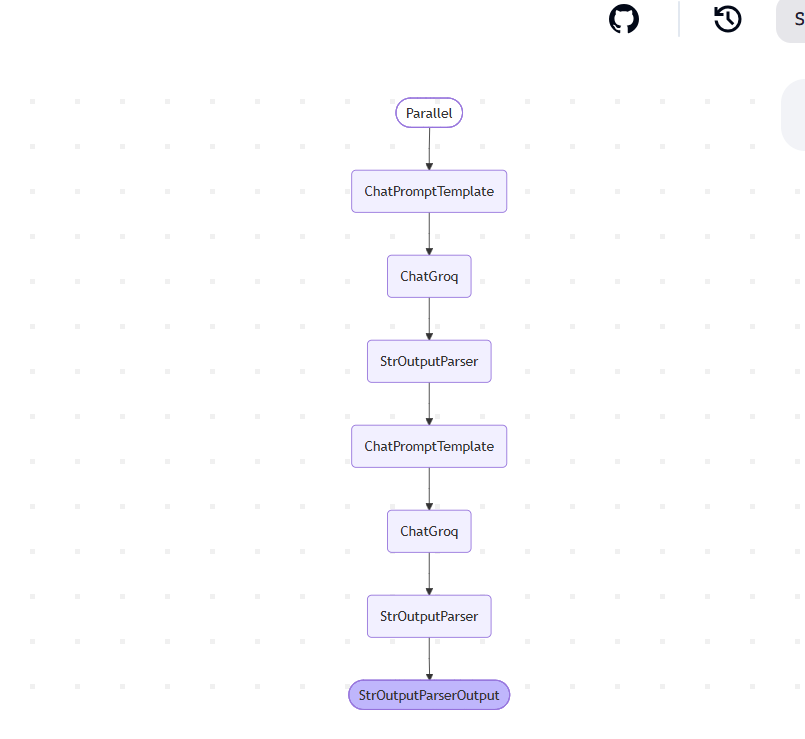

# **Parallel Chains**

In [14]:
from langchain_core.runnables import RunnableParallel

adv_prompt = ChatPromptTemplate.from_messages([
    ('system', 'You are an helpful assistant'),
    ('human', 'Give me the PROs on starting business {business}')
])

chain1 = adv_prompt | llm | StrOutputParser()

cons_prompt = ChatPromptTemplate.from_messages([
    ('system', 'You are an helpful assitant'),
('human', 'Give me CONs on starting business  {business}')
])

chain2 = cons_prompt | llm | StrOutputParser()

parallel_chains = RunnableParallel(
    advantages = chain1,
    disadvantages = chain2
)
business_name = input("Enter Your Business Name: ")
parallel_chains.invoke({"business" : business_name })

{'advantages': '### Pros of Starting a “Lifestyle” Business  \n\n| Benefit | Why It Matters |\n|--------|----------------|\n| **Flexibility & Freedom** | You set your own hours, work from anywhere, and can design a schedule that fits your personal life (travel, family, hobbies). |\n| **Lower Startup Costs** | Many lifestyle ventures (coaching, digital products, e‑commerce, freelance services) require minimal capital—often just a laptop, a website, and basic marketing tools. |\n| **Passion‑Driven Work** | You can build a business around something you love (travel, fitness, cooking, art, etc.), which boosts motivation and reduces burnout. |\n| **Scalable Simplicity** | You can start small (one‑person operation) and gradually add automation, outsourcing, or passive‑income streams without the pressure of rapid scaling. |\n| **Control Over Revenue Streams** | You can diversify income (e‑courses, memberships, affiliate commissions, consulting) and adjust the mix based on what works best for 

### **Flow Chart**
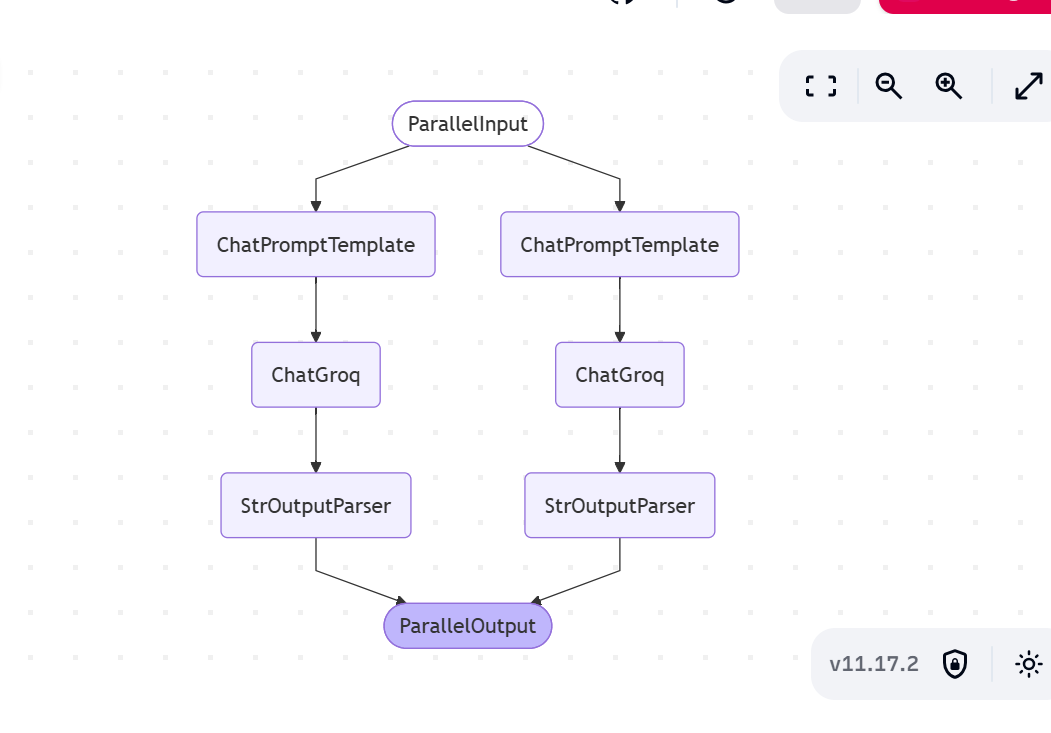

# **Conditional Chain**

In [ ]:
from langchain_core.runnables import RunnableBranch



---
config:
  flowchart:
    curve: linear
---
graph TD;
	Parallel\3cadvantages\2cdisadvantages\3eInput([Parallel<advantages,disadvantages>Input]):::first
	Parallel\3cadvantages\2cdisadvantages\3eOutput([Parallel<advantages,disadvantages>Output]):::last
	ChatPromptTemplate_1(ChatPromptTemplate)
	ChatGroq_1(ChatGroq)
	StrOutputParser_1(StrOutputParser)
	ChatPromptTemplate_2(ChatPromptTemplate)
	ChatGroq_2(ChatGroq)
	StrOutputParser_2(StrOutputParser)
	ChatPromptTemplate_1 --> ChatGroq_1;
	ChatGroq_1 --> StrOutputParser_1;
	Parallel\3cadvantages\2cdisadvantages\3eInput --> ChatPromptTemplate_1;
	StrOutputParser_1 --> Parallel\3cadvantages\2cdisadvantages\3eOutput;
	ChatPromptTemplate_2 --> ChatGroq_2;
	ChatGroq_2 --> StrOutputParser_2;
	Parallel\3cadvantages\2cdisadvantages\3eInput --> ChatPromptTemplate_2;
	StrOutputParser_2 --> Parallel\3cadvantages\2cdisadvantages\3eOutput;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc

